In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [2]:
df = pd.read_csv("../../data/smard.csv", delimiter=";")

In [3]:
df.head(5)

,timestamp,Wind Offshore,Wind Onshore,Solar,Grid Load,Residual Load,Forecast Wind + Solar,Forecast Grid load,Forecast Residual Load
0,2022-01-01 00:00,"5975,5","25570,25","2,0","43915,5","12367,75","31530,75","41989,5","10458,75"
1,2022-01-01 01:00,"5775,25","24318,25","2,0","41535,75","11440,25","30462,5","40105,5","9643,0"
2,2022-01-01 02:00,"5548,0","23169,5","2,0","40480,75","11761,25","29055,25","38784,0","9728,75"
3,2022-01-01 03:00,"5382,75","22092,5","2,0","39564,0","12086,75","27607,5","37751,0","10143,5"
4,2022-01-01 04:00,"5586,5","20607,0","2,0","39338,25","13142,75","26255,5","37877,25","11621,75"


In [4]:
df.rename(
    columns={
        "Wind Offshore": "wind_off",
        "Wind Onshore": "wind_on",
        "Forecast Wind + Solar": "fc_gen_wind_solar",
        "Forecast Grid load": "fc_grid_load",
        "Forecast Residual Load": "fc_res"
    },
    inplace=True
)
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.columns

Index(['timestamp', 'wind_off', 'wind_on', 'solar', 'grid_load',
       'residual_load', 'fc_gen_wind_solar', 'fc_grid_load', 'fc_res'],
      dtype='str')

In [5]:
df["timestamp"] = pd.to_datetime(df["timestamp"], format="%Y-%m-%d %H:%M")
df.dtypes

timestamp            datetime64[us]
wind_off                        str
wind_on                         str
solar                           str
grid_load                       str
residual_load                   str
fc_gen_wind_solar               str
fc_grid_load                    str
fc_res                          str
dtype: object

In [6]:
numeric_cols = df.columns.tolist()
numeric_cols.remove("timestamp")

for col in numeric_cols:
    df[col] = df[col].str.replace(",", ".")
    df[col] = df[col].astype(float)

df.dtypes

timestamp            datetime64[us]
wind_off                    float64
wind_on                     float64
solar                       float64
grid_load                   float64
residual_load               float64
fc_gen_wind_solar           float64
fc_grid_load                float64
fc_res                      float64
dtype: object

In [7]:
df["gen_total_simple"] = df[["wind_off","wind_on", "solar"]].sum(axis=1)
df["wind_total"] = df[["wind_off","wind_on"]].sum(axis=1)
df

,timestamp,wind_off,wind_on,solar,grid_load,residual_load,fc_gen_wind_solar,fc_grid_load,fc_res,gen_total_simple,wind_total
0,2022-01-01 00:00:00,5975.50,25570.25,2.00,43915.50,12367.75,31530.75,41989.50,10458.75,31547.75,31545.75
1,2022-01-01 01:00:00,5775.25,24318.25,2.00,41535.75,11440.25,30462.50,40105.50,9643.00,30095.50,30093.50
2,2022-01-01 02:00:00,5548.00,23169.50,2.00,40480.75,11761.25,29055.25,38784.00,9728.75,28719.50,28717.50
3,2022-01-01 03:00:00,5382.75,22092.50,2.00,39564.00,12086.75,27607.50,37751.00,10143.50,27477.25,27475.25
4,2022-01-01 04:00:00,5586.50,20607.00,2.00,39338.25,13142.75,26255.50,37877.25,11621.75,26195.50,26193.50
...,...,...,...,...,...,...,...,...,...,...,...
41102,2026-09-09 19:00:00,4565.06,16645.74,821.53,59391.73,37359.40,24408.66,59119.10,34710.44,22032.33,21210.80
41103,2026-09-09 20:00:00,4626.21,16411.40,0.15,57694.66,36656.91,24108.39,57158.21,33049.82,21037.76,21037.61
41104,2026-09-09 21:00:00,4395.91,17227.84,0.00,54371.73,32747.98,24877.49,54462.50,29585.01,21623.75,21623.75
41105,2026-09-09 22:00:00,4210.74,18383.80,0.00,51569.83,28975.29,24957.61,50765.98,25808.36,22594.54,22594.54


Example Plot for grid load after conversion:

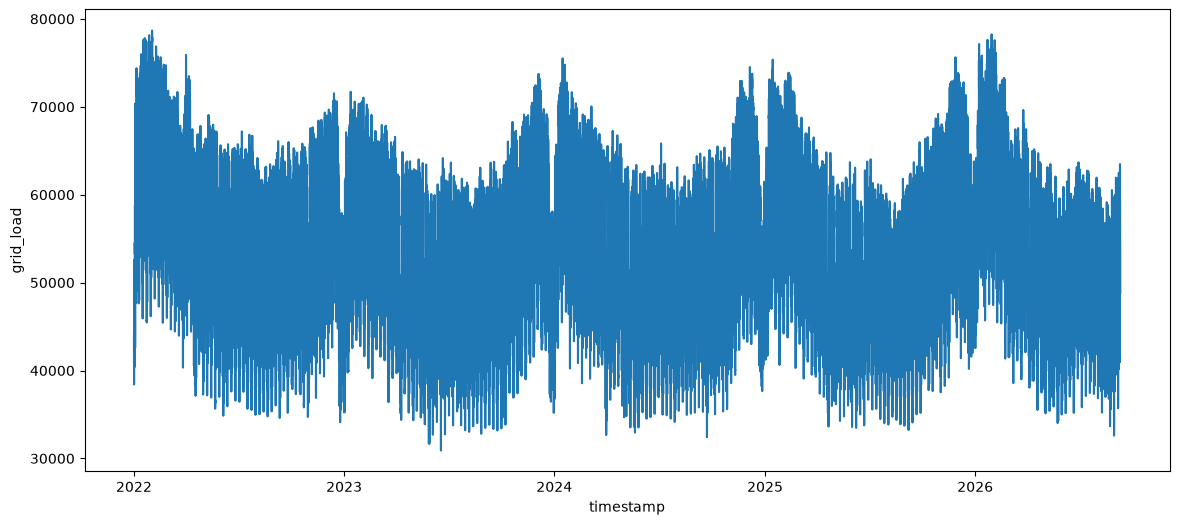

In [8]:
fig = plt.subplots(figsize=(14,6))
sns.lineplot(
    x="timestamp",
    y="grid_load",
    data=df
)
plt.show()

## Grid load over the full time range

- hourly series has daily and weekly cycle => raw line plot is mostly noise
- resampling to ``weekly`` and ``monthly`` shows the seasonal and year-over-year cycle

Our data starts mid-week (2022-01-01 = ``Saturday``) and ends (currently) on 2026-09-09 (Wednesday - mid September).

A .resample() would put a **fake dip** at each edge.

Dropping the artifacts get us **244 weeks** and **56 months** out of the 41,107 hourly rows.

In [9]:
# time-indexed copy, used for all resampling below
ts = df.set_index("timestamp").sort_index()

def period_mean(time_series, freq):
    """Mean of `time_series` per calendar period (`"W"`, `"M"`, ...), indexed by period start.

    Periods that the data does not cover completely (the first and last one) are
    dropped (not full weeks or months) so the edges of the plot are not partial-period artefacts.
    """
    agg = time_series.groupby(time_series.index.to_period(freq)).mean()

    complete = (
        agg.index.start_time >= time_series.index.min()) & (
        agg.index.end_time <= time_series.index.max() + pd.Timedelta("1h")
    )
    agg = agg[complete]
    agg.index = agg.index.start_time
    return agg


def style_timeseries(ax, title, ylabel="(MWh)"):
    """Custom grid, no box, year ticks."""
    ax.set_title(
        title,
        loc="center",
        fontsize=15,
        pad=12
    )
    ax.set_xlabel("")
    ax.set_ylabel(
        ylabel,
        color="grey"
    )
    ax.grid(
        axis="y",
        color="0.9",
        linewidth=0.8
    )
    ax.set_axisbelow(True)

    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    
    ax.tick_params(
        colors="black",
        length=0 # hide ticks of values
    )
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_minor_locator(mdates.MonthLocator((1, 4, 7, 10)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")


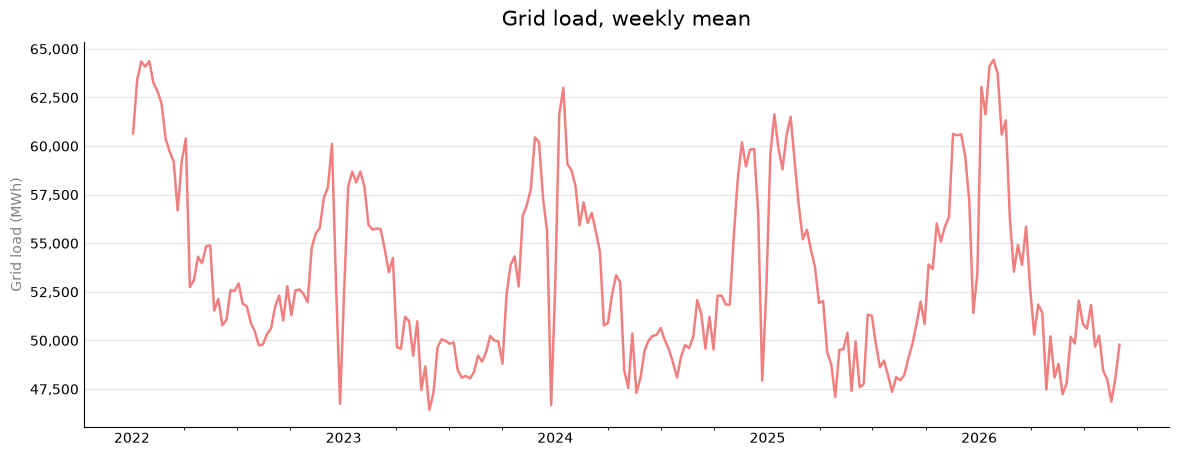

In [10]:
# Weekly Grid Load
weekly_grid_load = period_mean(ts["grid_load"], "W")
weekly_grid_load.shape

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    weekly_grid_load.index,
    weekly_grid_load.values,
    color="lightcoral",
    linewidth=1.8,
)
style_timeseries(ax, "Grid load, weekly mean", ylabel="Grid load (MWh)")
plt.show()

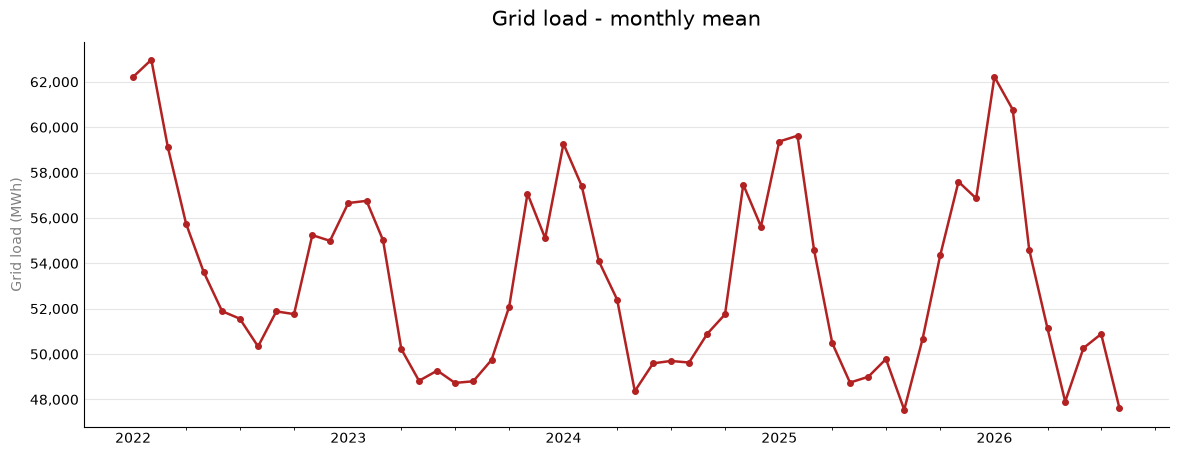

In [11]:
# Monthly Grid Load
monthly_grid_load = period_mean(ts["grid_load"], "M")
monthly_grid_load.shape

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    monthly_grid_load.index,
    monthly_grid_load.values,
    color="firebrick",
    linewidth=1.8,
    marker="o",
    markersize=4
)
style_timeseries(ax, "Grid load - monthly mean", ylabel="Grid load (MWh)")
plt.show()

### Hourly vs. the aggregates

Same data at all three resolutions, to see how much the resampling actually removes.

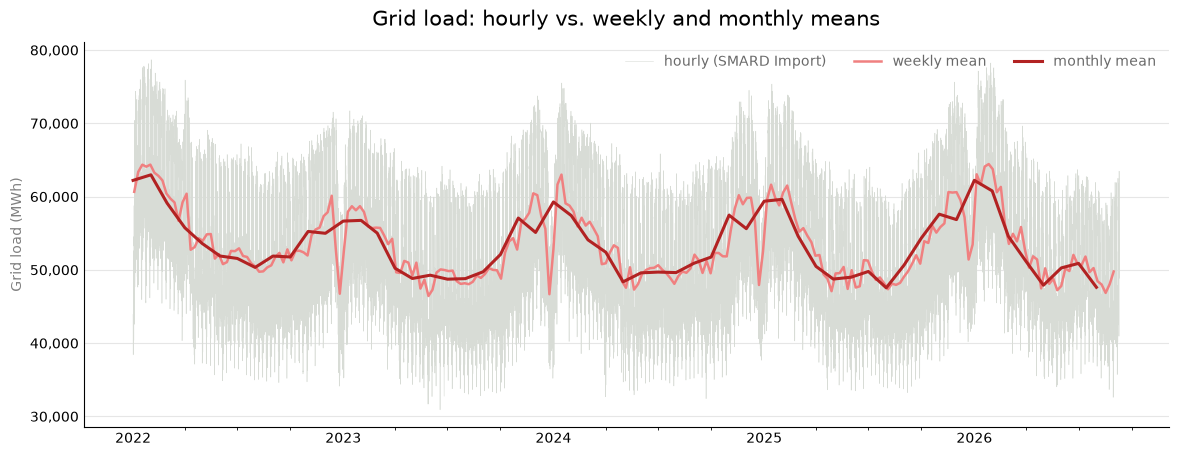

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))

# Raw Grid Load
ax.plot(
    ts.index,
    ts["grid_load"],
    color="xkcd:light grey",
    linewidth=0.4,
    label="hourly (SMARD Import)"
)

# Weekly aggregate
ax.plot(
    weekly_grid_load.index,
    weekly_grid_load.values,
    color="lightcoral",
    linewidth=1.8,
    label="weekly mean"
)

# Monthly aggregate
ax.plot(
    monthly_grid_load.index,
    monthly_grid_load.values,
    color="firebrick",
    linewidth=2.2,
    label="monthly mean"
)

style_timeseries(ax, "Grid load: hourly vs. weekly and monthly means", ylabel="Grid load (MWh)")
ax.legend(
    frameon=False,
    loc="upper right",
    ncols=3,
    labelcolor="dimgrey"
)
plt.show()

- clear annual cycle
- **peak** in winter
- **huge drop** on ``christmas / new years eve``

### Daylight saving time gaps

All gaps appear during the ``spring time`` shift at 02:00 AM (local)

There is **no gap** in the autumn shift - the data was already cleaned up by SMARD probably.

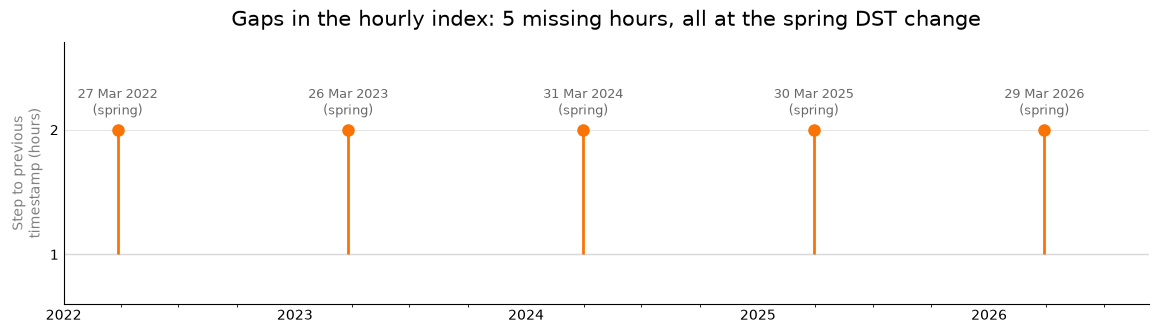

In [14]:
gaps = ts.index.to_series().diff()
gaps = gaps[gaps > pd.Timedelta("1h")].dt.total_seconds() / 3600

fig, ax = plt.subplots(figsize=(14, 3.4))

ax.axhline(
    1,
    color="0.85",
    linewidth=1
)
ax.vlines(
    gaps.index,
    1,
    gaps.values,
    color="xkcd:orange",
    linewidth=2
)
ax.plot(
    gaps.index,
    gaps.values,
    "o",
    color="xkcd:orange",
    markersize=8
)
for t, hours in gaps.items():
    ax.annotate(
        t.strftime("%d %b %Y") + "\n(spring)",
        (t, hours),
        textcoords="offset points",
        xytext=(0, 11),
        ha="center",
        fontsize=9,
        color="dimgrey"
    )

ax.set_xlim(ts.index.min(), ts.index.max())
ax.set_ylim(0.6, 2.7)
ax.set_yticks([1, 2])
style_timeseries(
    ax,
    f"Gaps in the hourly index: {len(gaps)} missing hours, all at the spring DST change",
    ylabel="Step to previous\ntimestamp (hours)",
)
plt.show()

## Generation over the full time range

### Solar + Wind

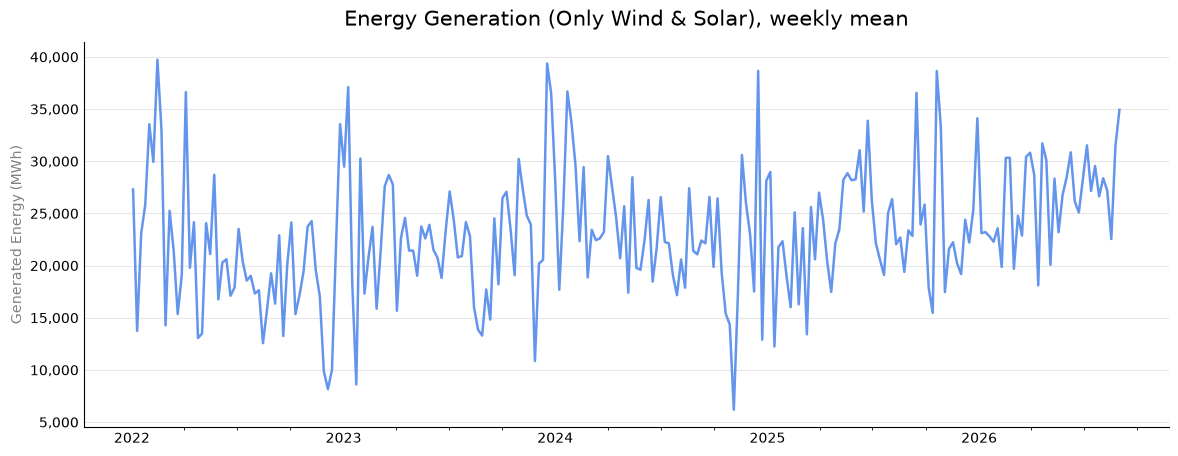

In [15]:
# Weekly Generation
weekly_generation_simple = period_mean(ts["gen_total_simple"], "W")
weekly_generation_simple.shape

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    weekly_generation_simple.index,
    weekly_generation_simple.values,
    color="cornflowerblue",
    linewidth=1.8
)
style_timeseries(ax, "Energy Generation (Only Wind & Solar), weekly mean", ylabel="Generated Energy (MWh)")
plt.show()

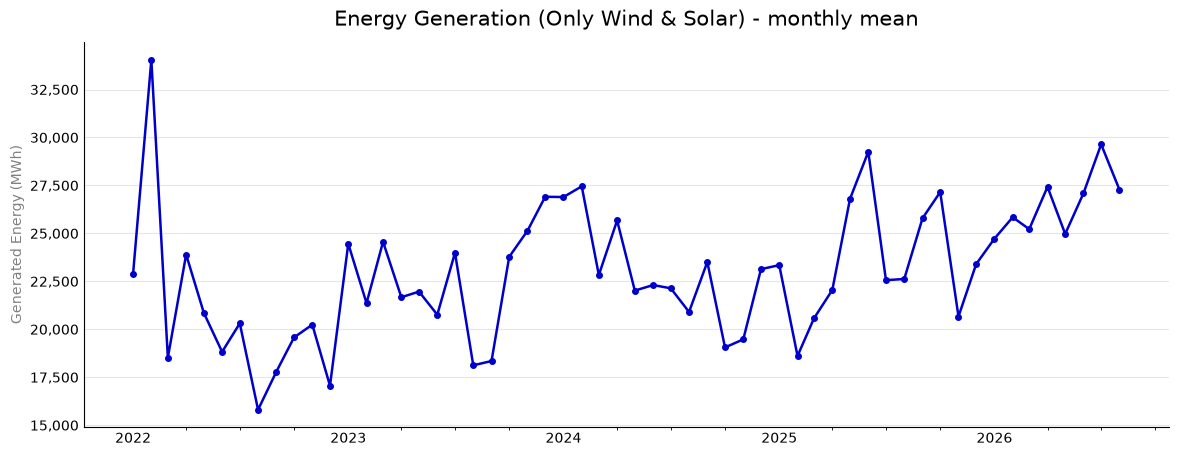

In [16]:
# Monthly Grid Load
monthly_generation_simple = period_mean(ts["gen_total_simple"], "M")
monthly_generation_simple.shape

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    monthly_generation_simple.index,
    monthly_generation_simple.values,
    color="mediumblue",
    linewidth=1.8,
    marker="o",
    markersize=4
)
style_timeseries(ax, "Energy Generation (Only Wind & Solar) - monthly mean", ylabel="Generated Energy (MWh)")
plt.show()

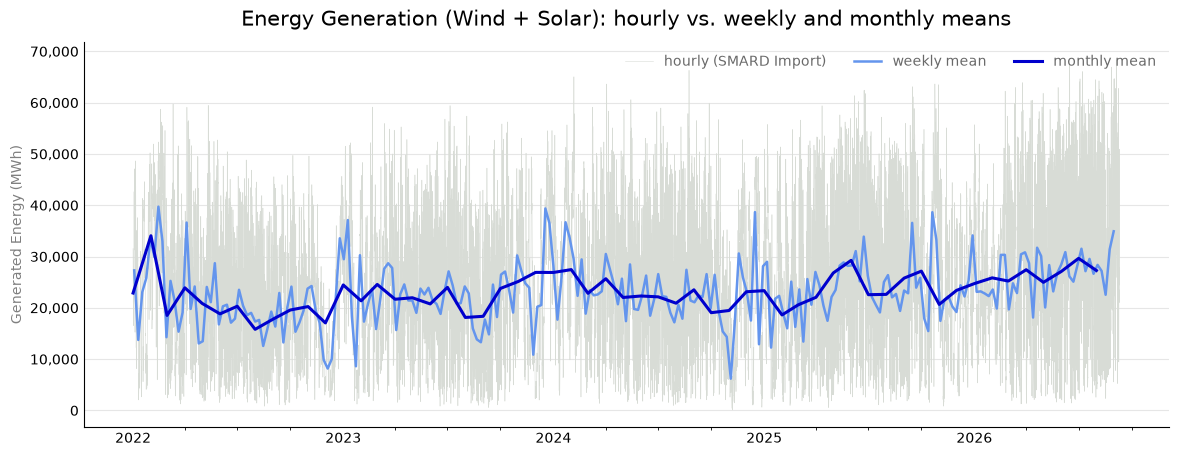

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))

# Raw Generation
ax.plot(
    ts.index,
    ts["gen_total_simple"],
    color="xkcd:light grey",
    linewidth=0.4,
    label="hourly (SMARD Import)"
)

# Weekly aggregate Generation
ax.plot(
    weekly_generation_simple.index,
    weekly_generation_simple.values,
    color="cornflowerblue",
    linewidth=1.8,
    label="weekly mean"
)

# Monthly aggregate Generation
ax.plot(
    monthly_generation_simple.index,
    monthly_generation_simple.values,
    color="mediumblue",
    linewidth=2.2,
    label="monthly mean"
)

style_timeseries(ax, "Energy Generation (Wind + Solar): hourly vs. weekly and monthly means", ylabel="Generated Energy (MWh)")
ax.legend(
    frameon=False,
    loc="upper right",
    ncols=3,
    labelcolor="dimgrey"
)
plt.show()

### Solar (solo)

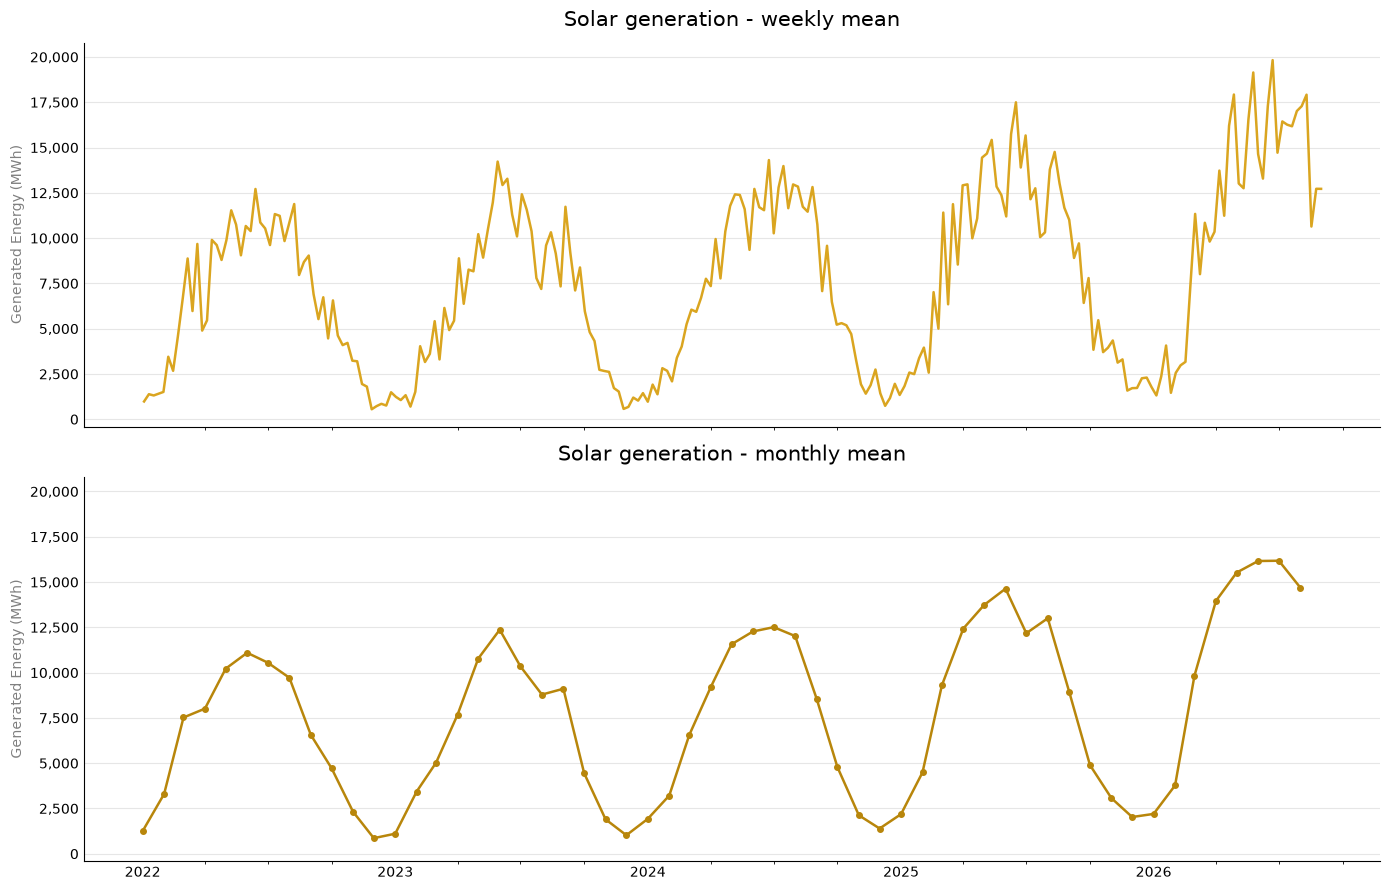

In [18]:
# Weekly + Monthly Solar
weekly_solar = period_mean(ts["solar"], "W")
monthly_solar = period_mean(ts["solar"], "M")

fig, (ax_weekly, ax_monthly) = plt.subplots(
    2, 1,
    figsize=(14, 9),
    sharex=True,
    sharey=True
)

# Weekly aggregate Solar
ax_weekly.plot(
    weekly_solar.index,
    weekly_solar.values,
    color="goldenrod",
    linewidth=1.8
)
style_timeseries(ax_weekly, "Solar generation - weekly mean", ylabel="Generated Energy (MWh)")

# Monthly aggregate Solar
ax_monthly.plot(
    monthly_solar.index,
    monthly_solar.values,
    color="darkgoldenrod",
    linewidth=1.8,
    marker="o",
    markersize=4
)
style_timeseries(ax_monthly, "Solar generation - monthly mean", ylabel="Generated Energy (MWh)")

fig.tight_layout()
plt.show()

- `solar` peaks are **higher with each year**
- most production during summer (expected)

### Wind (solo)

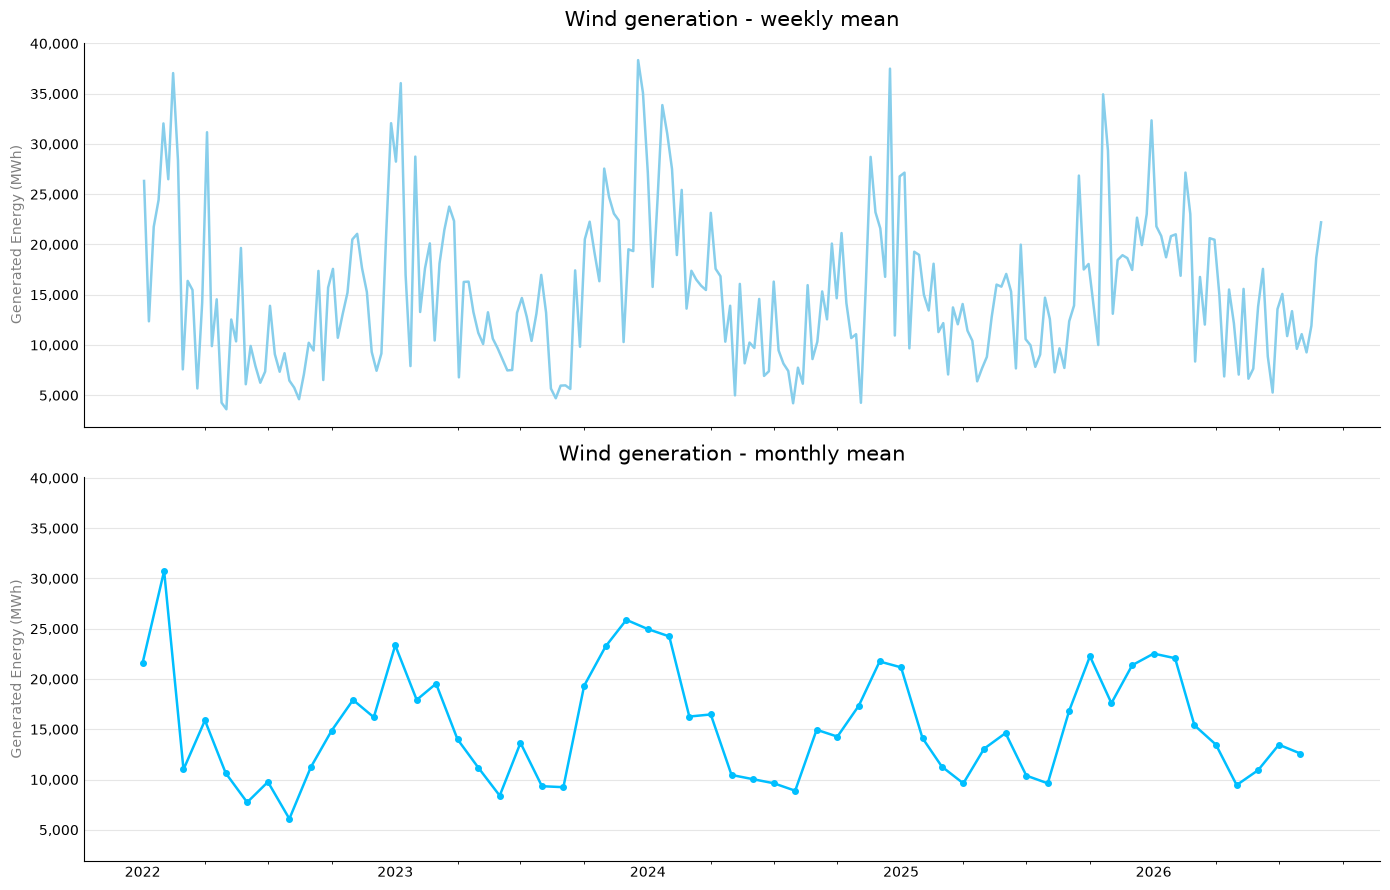

In [19]:
# Weekly + Monthly Wind
weekly_wind = period_mean(ts["wind_total"], "W")
monthly_wind = period_mean(ts["wind_total"], "M")

fig, (ax_weekly, ax_monthly) = plt.subplots(
    2, 1,
    figsize=(14, 9),
    sharex=True,
    sharey=True
)

# Weekly aggregate Wind
ax_weekly.plot(
    weekly_wind.index,
    weekly_wind.values,
    color="skyblue",
    linewidth=1.8
)
style_timeseries(ax_weekly, "Wind generation - weekly mean", ylabel="Generated Energy (MWh)")

# Monthly aggregate Wind
ax_monthly.plot(
    monthly_wind.index,
    monthly_wind.values,
    color="deepskyblue",
    linewidth=1.8,
    marker="o",
    markersize=4
)
style_timeseries(ax_monthly, "Wind generation - monthly mean", ylabel="Generated Energy (MWh)")

fig.tight_layout()
plt.show()

- `wind` generation highly irratic
- higher generation in **autumn / winter**

### Solar and Wind Monthly

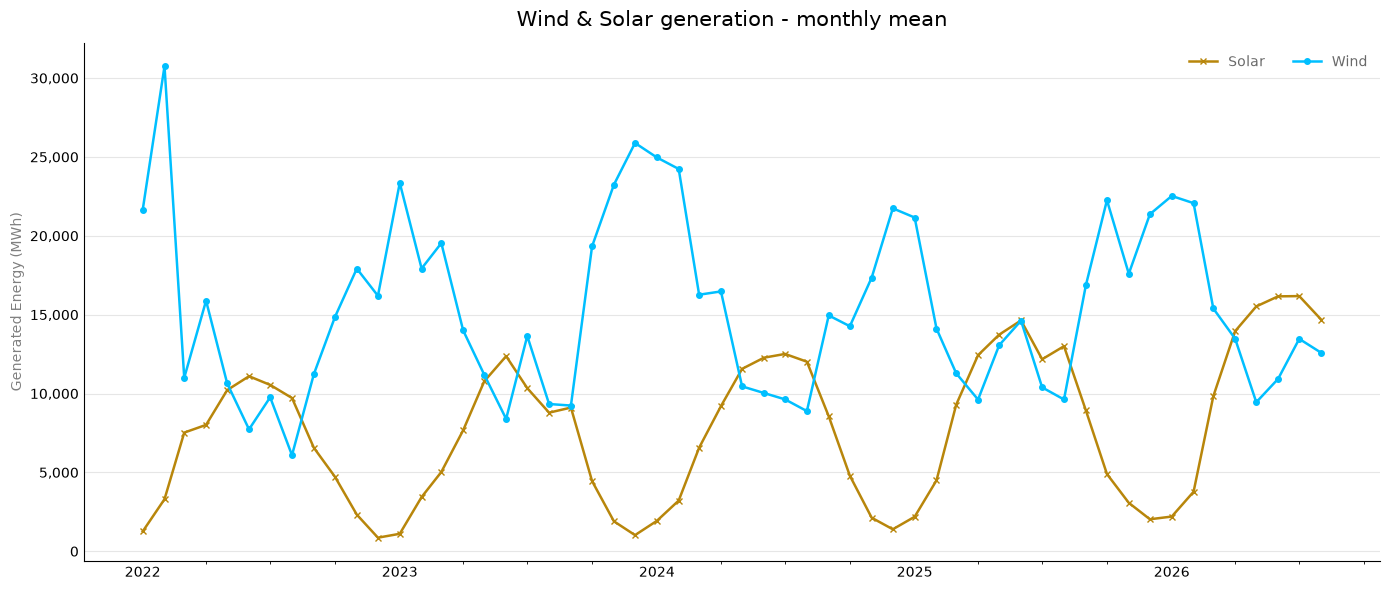

In [20]:
# Monthly plots for wind and solar

fig, ax = plt.subplots(
    figsize=(14, 6),
)

# Monthly aggregate Solar
ax.plot(
    monthly_solar.index,
    monthly_solar.values,
    color="darkgoldenrod",
    linewidth=1.8,
    marker="x",
    markersize=4,
    label="Solar"
)

# Monthly aggregate Wind
ax.plot(
    monthly_wind.index,
    monthly_wind.values,
    color="deepskyblue",
    linewidth=1.8,
    marker="o",
    markersize=4,
    label="Wind"
)
style_timeseries(ax, "Wind & Solar generation - monthly mean", ylabel="Generated Energy (MWh)")
ax.legend(
    frameon=False,
    loc="upper right",
    ncols=3,
    labelcolor="dimgrey"
)
plt.tight_layout()
plt.show()

- solar and wind **peaks** are reversed to each other

# Seasonal Plots

In [21]:
def seasonal_plot(df, y_value, title, ylabel="(MWh)"):
    """Creates a seasonal plot from a dataframe

    Args:
        df (Dataframe): Dataframe with separate month and year columns
        y_value (str): Name of the y-value to plot
        title (str): Title of the plot
        ylabel (str, optional): Axis Description. Defaults to "(MWh)".
    """
    fig, ax = plt.subplots(figsize=(14, 5))

    sns.lineplot(
        data=df,
        x="month",
        y=y_value,
        hue="year",
        palette="viridis",
        legend=True,
        ax=ax
    )
    ax.set_xlabel("Month")
    ax.set_ylabel("MWh")
    ax.set_title(title)
    ax.set_xticks(range(1, 13))
    plt.tight_layout()
    plt.show()

## Grid Load

In [22]:
monthly_grid_load_df = monthly_grid_load.to_frame()

monthly_grid_load_df = monthly_grid_load_df.assign(
    year=monthly_grid_load_df.index.year,
    month=monthly_grid_load_df.index.month
)

monthly_grid_load_df.head(3)

,grid_load,year,month
timestamp,,,
2022-01-01,62213.815860,2022,1
2022-02-01,62973.063988,2022,2
2022-03-01,59116.096231,2022,3


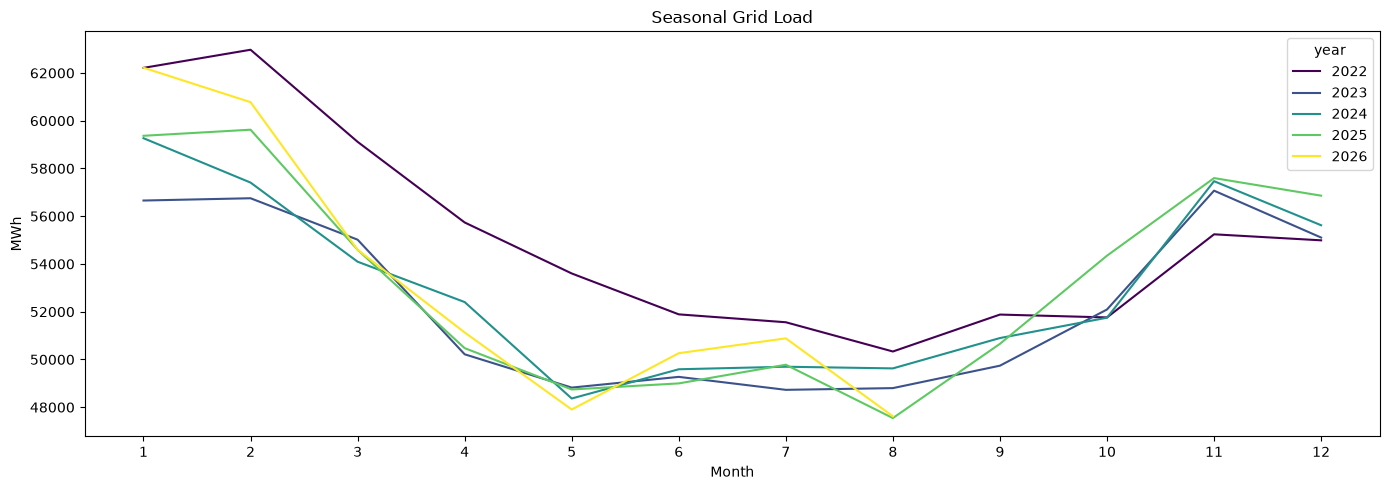

In [23]:
seasonal_plot(monthly_grid_load_df, "grid_load", "Seasonal Grid Load")

## Energy Generation

In [24]:
monthly_generation_df = monthly_generation_simple.to_frame()

monthly_generation_df = monthly_generation_df.assign(
    year=monthly_generation_df.index.year,
    month=monthly_generation_df.index.month
)

monthly_generation_df.head(3)

,gen_total_simple,year,month
timestamp,,,
2022-01-01,22883.231183,2022,1
2022-02-01,34050.985119,2022,2
2022-03-01,18519.691117,2022,3


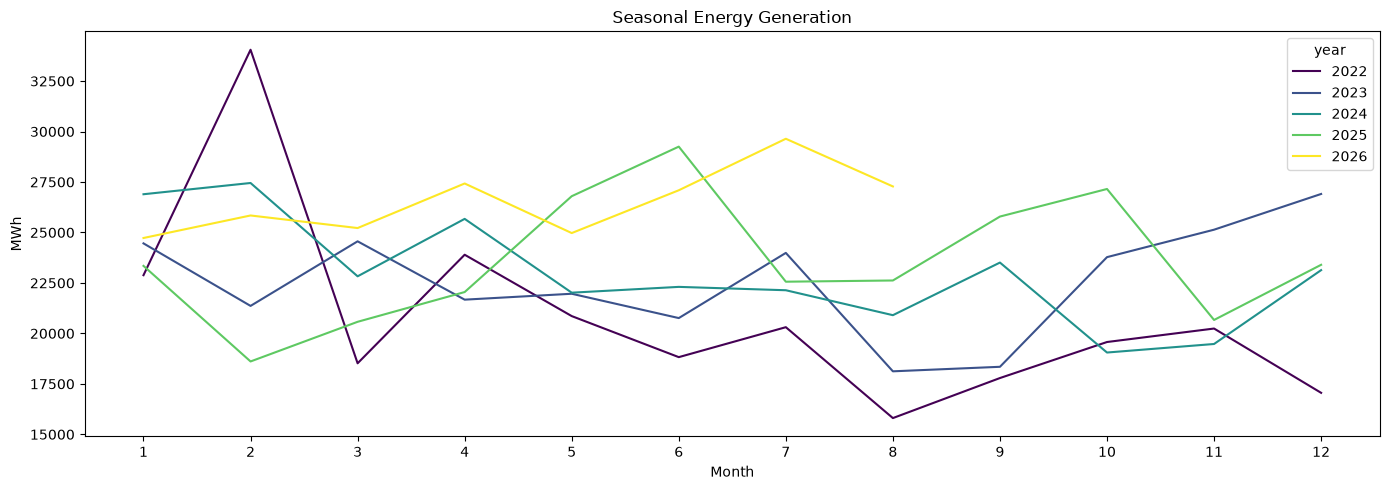

In [25]:
seasonal_plot(monthly_generation_df, "gen_total_simple", "Seasonal Energy Generation")

## Residual Load

In [26]:
# Monthly Residual Load
monthly_residual_load = period_mean(ts["residual_load"], "M")
monthly_residual_load.shape

(56,)

In [27]:
monthly_residual_df = monthly_residual_load.to_frame()

monthly_residual_df = monthly_residual_df.assign(
    year=monthly_residual_df.index.year,
    month=monthly_residual_df.index.month
)

monthly_residual_df.head(3)

,residual_load,year,month
timestamp,,,
2022-01-01,39330.584677,2022,1
2022-02-01,28922.078869,2022,2
2022-03-01,40596.405114,2022,3


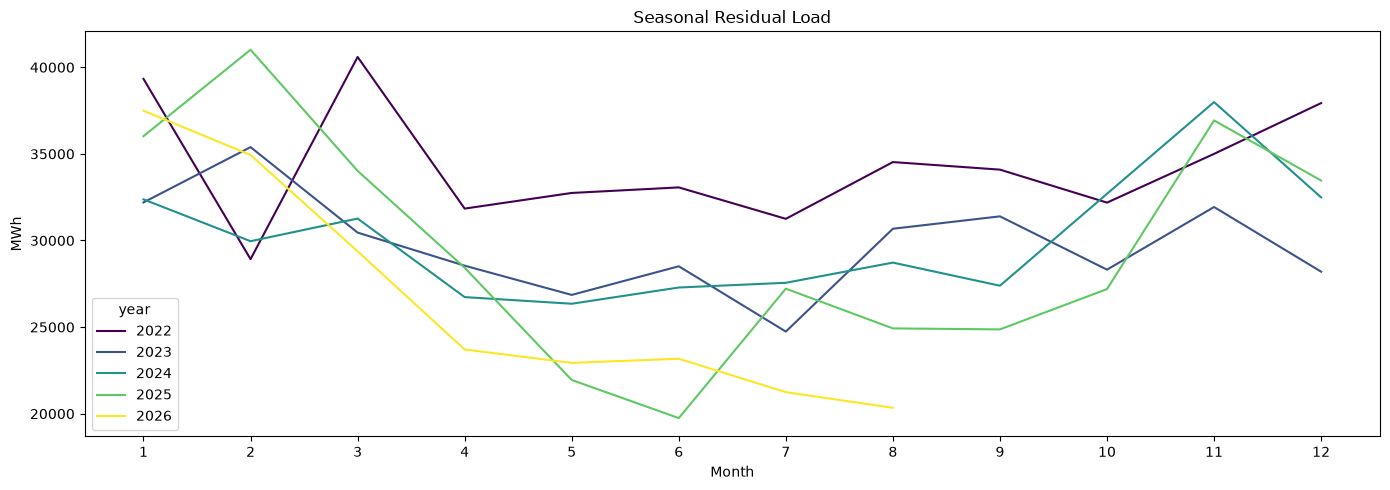

In [28]:
seasonal_plot(monthly_residual_df, "residual_load", "Seasonal Residual Load")